# This is a lab for Model Development

We will try to predict future observations from the data we have.
This is a introduction por IA and ML, the first step is know about Linear Regression, evaluation metrics (acurracy, MSE, RMSE, etc).
1. Import Libraries and load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# import dataset automobile EDA
path = '../data/automobileEDA.csv'
df = pd.read_csv(path)
df.head(5)

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


## Linear Regression and multiple Linear Regression

Steps for use LR with Scikit-learn
1. Create the linear regression object
2. Define what is our response variable _(Y)_ and predictor variable _(X)_, we must to know the correlation between this two variables.
3. Fit the model
4. Try to predict with the model

             engine-size     price
engine-size     1.000000  0.872335
price           0.872335  1.000000
<class 'pandas.core.frame.DataFrame'>
[[166.86001569]]
[-7963.33890628]
   engine-size
0     13727.94
1     13727.94
2     17398.86
3     10223.88
4     14729.10


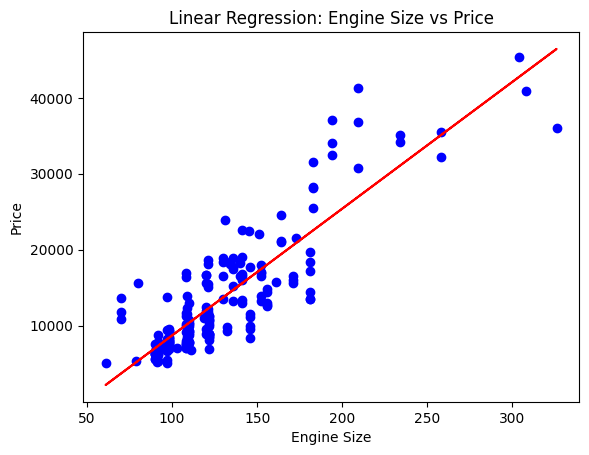

[   1.49789586 -820.45434016]
38201.31327245728
0    16231.789383
1    16231.789383
2    17052.243724
3    13833.337989
4    20396.972710
dtype: float64


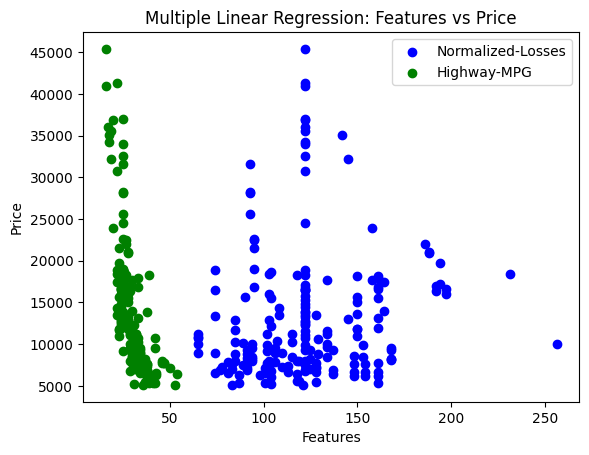

In [2]:
# Before we import the library Scikit-Learn
lr = LinearRegression() # Create a object
print(df[['engine-size', 'price']].corr()) # corr = 0.87 -> Twice variables has a positive corr
X = df[['engine-size']]
Y = df[['price']]
print(type(Y))
lr.fit(X=X, y=Y)
print(lr.coef_)
print(lr.intercept_)
y_hat = -7963.86 + 166.86*X # 
print(y_hat[:5])

# Plotting the regression line
plt.scatter(X, Y, color='blue') # Scatter plot of the data points
plt.plot(X, y_hat, color='red') # Regression line
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Linear Regression: Engine Size vs Price')
plt.show()

# also we could implement a multiple linear regression with more features
lr_multi = LinearRegression()
lr_multi.fit(df[['normalized-losses', 'highway-mpg']], df['price'])
print(lr_multi.coef_)
print(lr_multi.intercept_)
y_hat_multi = lr_multi.intercept_ + lr_multi.coef_[0]*df['normalized-losses'] + lr_multi.coef_[1]*df['highway-mpg']
print(y_hat_multi[:5])
# Plotting the regression line for multiple linear regression
plt.scatter(df['normalized-losses'], df['price'], color='blue', label='Normalized-Losses')
plt.scatter(df['highway-mpg'], df['price'], color='green', label='Highway-MPG')
plt.xlabel('Features')
plt.ylabel('Price')
plt.title('Multiple Linear Regression: Features vs Price')
plt.legend()
plt.show()


# Model Evaluation and refinement

## Part 1. Train test

   Unnamed: 0.1  Unnamed: 0  symboling  normalized-losses  wheel-base  \
0             0           0          3                122        88.6   
1             1           1          3                122        88.6   
2             2           2          1                122        94.5   
3             3           3          2                164        99.8   
4             4           4          2                164        99.4   

     length     width  height  curb-weight  engine-size  ...  stroke  \
0  0.811148  0.890278    48.8         2548          130  ...    2.68   
1  0.811148  0.890278    48.8         2548          130  ...    2.68   
2  0.822681  0.909722    52.4         2823          152  ...    3.47   
3  0.848630  0.919444    54.3         2337          109  ...    3.40   
4  0.848630  0.922222    54.3         2824          136  ...    3.40   

   compression-ratio  horsepower  peak-rpm  city-mpg  highway-mpg    price  \
0                9.0       111.0    5000.0        

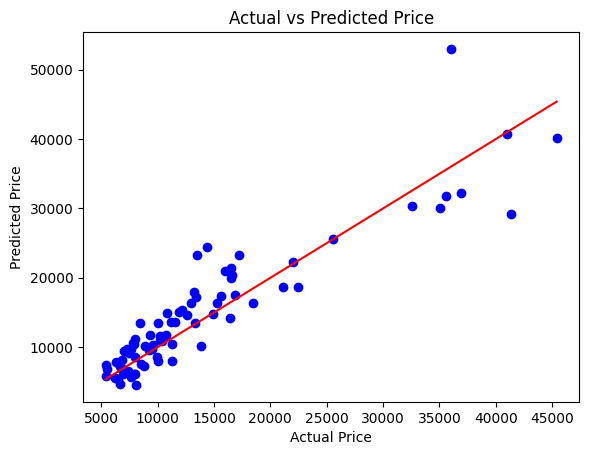

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

df = pd.read_csv('../data/module_5_auto.csv')
df = df._get_numeric_data().dropna()

print(df.head(5))

x_train, x_test, y_train, y_test = train_test_split(df.drop('price', axis=1), df['price'], test_size=0.40, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R^2 Score:', r2_score(y_test, y_pred))

# Plotting the predicted vs actual values
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red') # Line for perfect predictions
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()


## 2. Cross validation

Cross-Validation MSE Scores: [17104725.60894769 15833854.49277812 20047698.10097692 15799885.62914772
  9782549.099103  ]
Average Cross-Validation MSE: 15713742.586190691


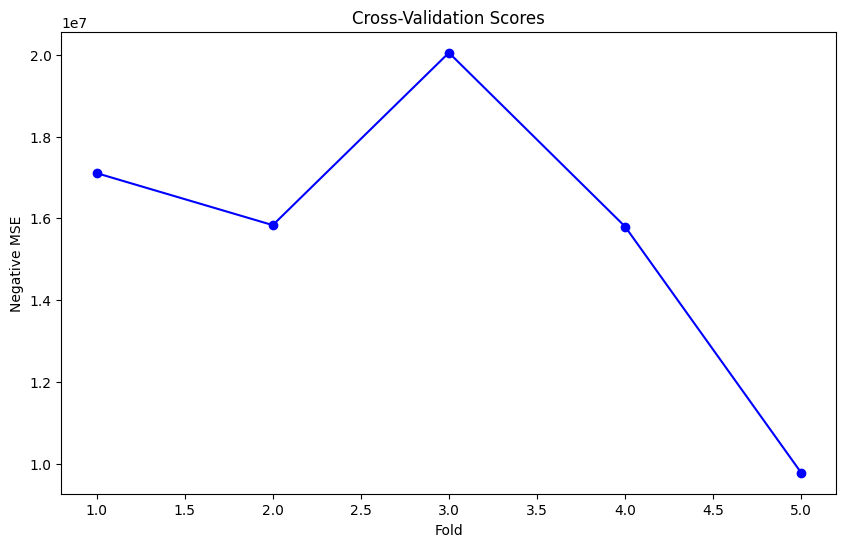

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
cv_scores = cross_val_score(lr, df.drop('price', axis=1), df['price'], cv=5, scoring='neg_mean_squared_error')
print('Cross-Validation MSE Scores:', -cv_scores)
print('Average Cross-Validation MSE:', -cv_scores.mean())

#plotting the cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), -cv_scores, marker='o', linestyle='-', color='blue')
plt.xlabel('Fold')
plt.ylabel('Negative MSE')
plt.title('Cross-Validation Scores')
plt.show()

## Overfitting, Underfitting and Model Selection

[[12760.94140248]
 [12760.94140248]
 [17110.55403179]
 [ 9556.00344044]
 [13863.73916717]]


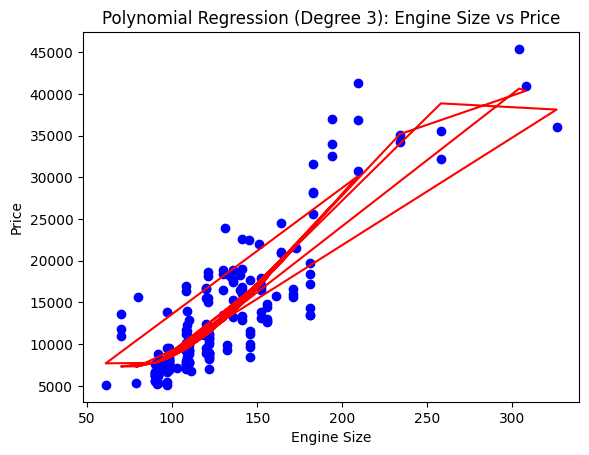

[[13728.4631336 ]
 [13728.4631336 ]
 [17399.38347881]
 [10224.40280408]
 [14729.62322775]]


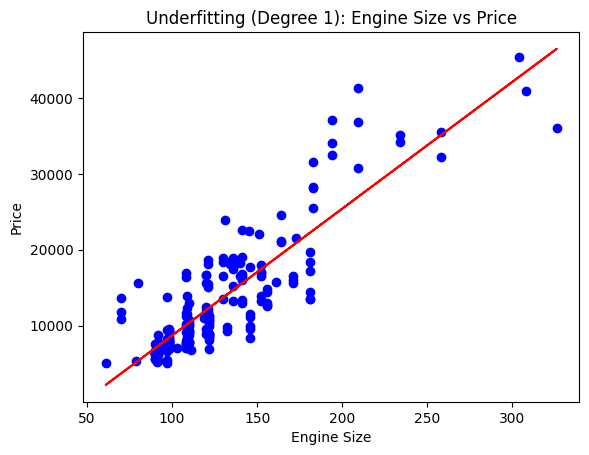

In [7]:
# overfitting and underfitting
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
# Create a pipeline that includes polynomial features and linear regression
degree = 3
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
# Fit the model to the data
model.fit(X, Y)
#predicting the values using the model
y_hat_poly = model.predict(X)
print(y_hat_poly[:5])
# Plotting the polynomial regression line
plt.scatter(X, Y, color='blue') # Scatter plot of the data points
plt.plot(X, y_hat_poly, color='red') # Polynomial regression line
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title(f'Polynomial Regression (Degree {degree}): Engine Size vs Price')
plt.show()

# underfitting example with degree 1 (linear regression)
degree = 1
model_underfit = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_underfit.fit(X, Y)
y_hat_underfit = model_underfit.predict(X)
print(y_hat_underfit[:5])
# Plotting the underfitting regression line
plt.scatter(X, Y, color='blue') # Scatter plot of the data points
plt.plot(X, y_hat_underfit, color='red') # Underfitting regression line
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title(f'Underfitting (Degree {degree}): Engine Size vs Price')
plt.show()

## Ridge regression

[13728.46162349 13728.46162349 17399.37133541 10224.41144394
 14729.61881765]


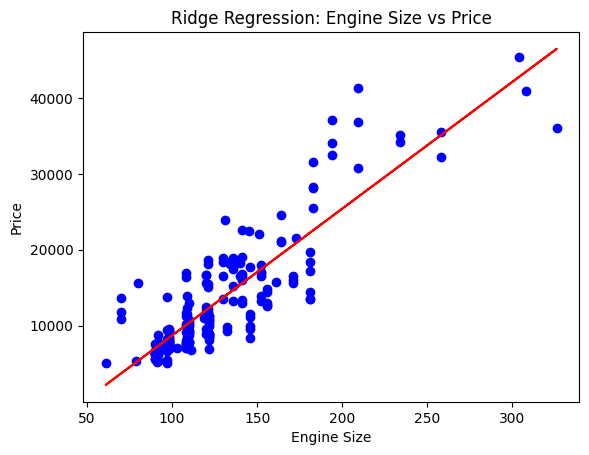

In [8]:
# ridge regression example
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X, Y)
y_hat_ridge = ridge.predict(X)
print(y_hat_ridge[:5])
# Plotting the ridge regression line
plt.scatter(X, Y, color='blue') # Scatter plot of the data points
plt.plot(X, y_hat_ridge, color='red') # Ridge regression line
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Ridge Regression: Engine Size vs Price')
plt.show()


## Gridge Search

Best Parameters: {'alpha': 100.0}
Best Score: 16581352.188041616


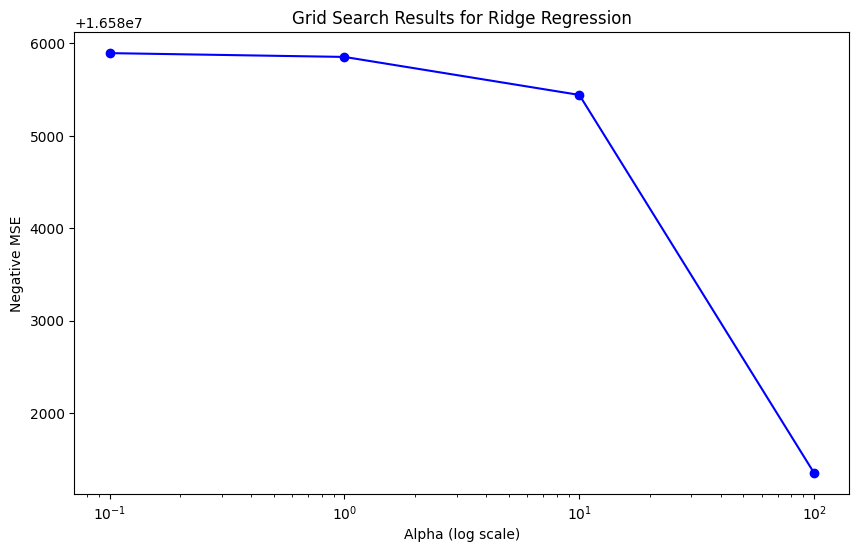

In [9]:
# grid search example for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
ridge = Ridge()
parameters = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(estimator=ridge, param_grid=parameters, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X, Y)
print('Best Parameters:', grid_search.best_params_)
print('Best Score:', -grid_search.best_score_)
#plotting the grid search results
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(results['param_alpha'], -results['mean_test_score'], marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Negative MSE')
plt.title('Grid Search Results for Ridge Regression')
plt.show()